In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set style untuk plot
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("="*60)
print("LSTM STOCK PRICE PREDICTION - ALIBABA (BABA)")
print("="*60)

LSTM STOCK PRICE PREDICTION - ALIBABA (BABA)


In [ ]:
# 1. LOAD DATA
df = pd.read_csv('BABA.csv',skiprows=2)
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
print(df)

            Date       Close        High        Low        Open    Volume
0     2015-01-02  100.051353  101.132992  99.008345  100.669431  12303400
1     2015-01-05   97.540405   99.491210  96.478086   99.240121  18337000
2     2015-01-06   99.780937  100.292782  96.680892   97.781842  15720400
3     2015-01-07   98.631699  101.152298  98.535125  101.007434  11052200
4     2015-01-08  101.432373  101.731752  99.162870   99.423618  12942100
...          ...         ...         ...        ...         ...       ...
2510  2024-12-23   85.139999   85.309998  82.769997   82.849998  20055100
2511  2024-12-24   85.519997   85.889999  85.000000   85.699997   5235400
2512  2024-12-26   86.080002   87.269997  85.559998   85.720001  12008600
2513  2024-12-27   85.059998   85.269997  84.290001   84.889999   8629400
2514  2024-12-30   84.129997   84.949997  83.529999   84.169998  10731000

[2515 rows x 6 columns]


In [ ]:
# Konversi 'Date' menjadi datetime dan ubah kolom lainnya menjadi numerik
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df['High'] = pd.to_numeric(df['High'], errors='coerce')
df['Low'] = pd.to_numeric(df['Low'], errors='coerce')
df['Open'] = pd.to_numeric(df['Open'], errors='coerce')
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

In [ ]:
# Hapus baris dengan NaN (biasanya dari parsing yang gagal)
df = df.dropna().copy()

# Urutkan berdasarkan tanggal
df = df.sort_values('Date').reset_index(drop=True)

In [ ]:
# Basic statistics
print("\nBasic Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Basic Statistics:
                                Date        Close         High          Low  \
count                           2515  2515.000000  2515.000000  2515.000000   
mean   2019-12-31 01:37:54.512922624   132.155072   133.871127   130.411645   
min              2015-01-02 00:00:00    55.424198    56.641038    55.240704   
25%              2017-07-01 12:00:00    82.001545    82.997168    81.170503   
50%              2019-12-31 00:00:00   108.955536   110.915999   106.531515   
75%              2022-06-29 12:00:00   174.664932   176.843662   172.434058   
max              2024-12-30 00:00:00   306.276886   308.382206   298.328791   
std                              NaN    57.411061    58.025260    56.719975   

              Open        Volume  
count  2515.000000  2.515000e+03  
mean    132.252885  1.865308e+07  
min      55.337277  3.775300e+06  
25%      82.136757  1.182095e+07  
50%     109.235601  1.588420e+07  
75%     174.645625  2.133240e+07  
max     302.761578  1.59

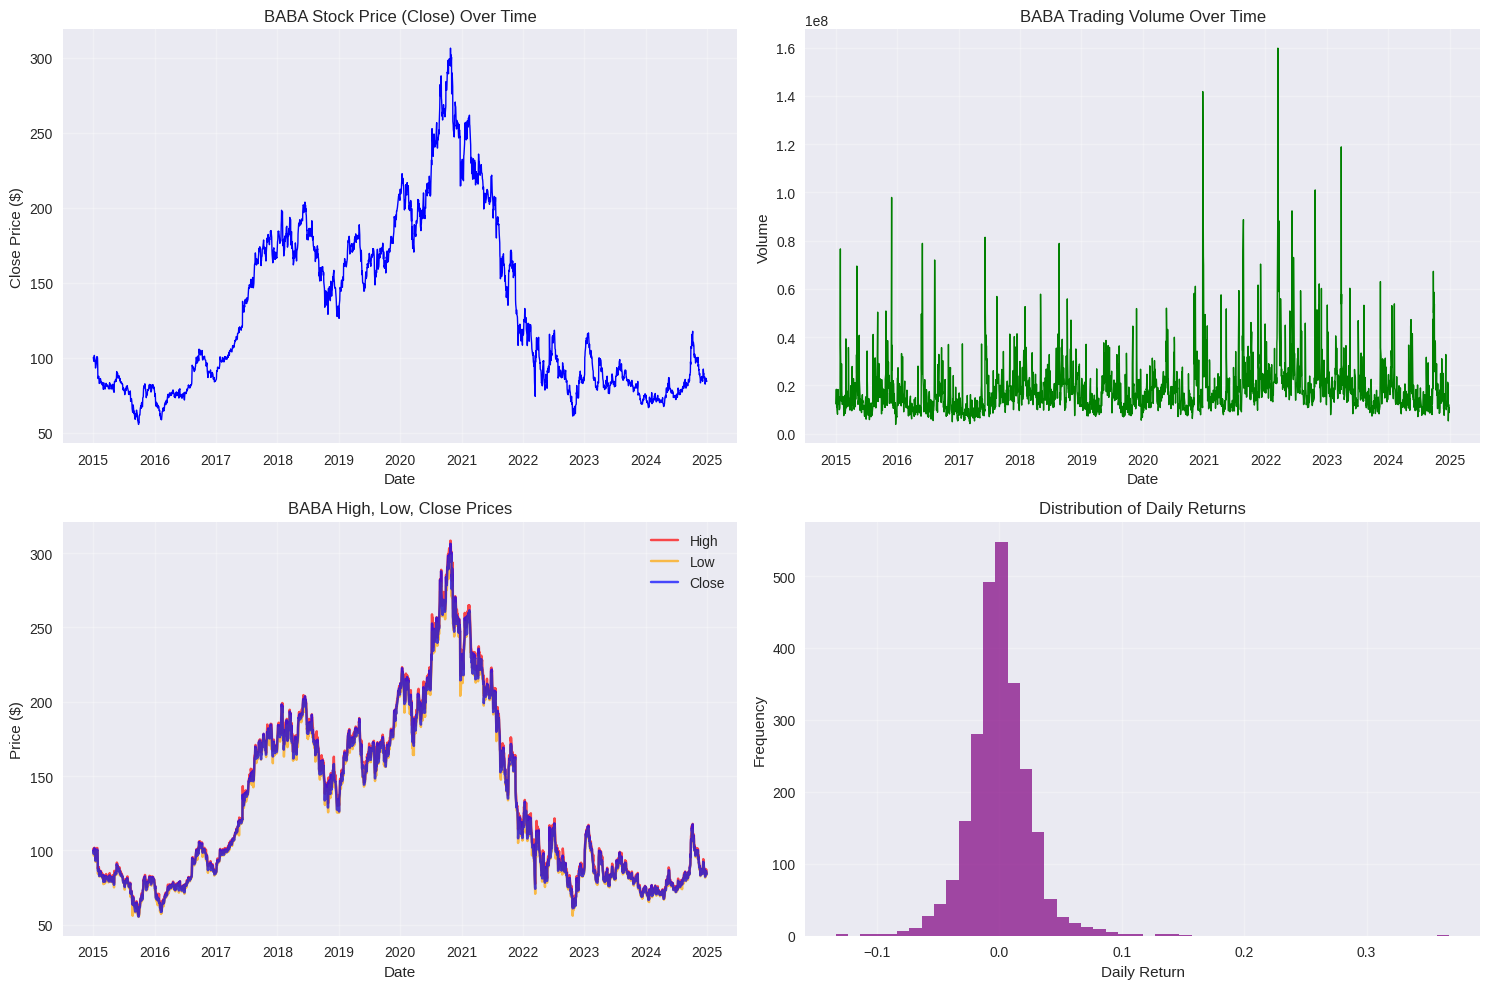

In [ ]:
# Plot stock price over time
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(df['Date'], df['Close'], color='blue', linewidth=1)
plt.title('BABA Stock Price (Close) Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(df['Date'], df['Volume'], color='green', linewidth=1)
plt.title('BABA Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(df['Date'], df['High'], color='red', alpha=0.7, label='High')
plt.plot(df['Date'], df['Low'], color='orange', alpha=0.7, label='Low')
plt.plot(df['Date'], df['Close'], color='blue', alpha=0.7, label='Close')
plt.title('BABA High, Low, Close Prices')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
df['Daily_Return'] = df['Close'].pct_change()
plt.hist(df['Daily_Return'].dropna(), bins=50, alpha=0.7, color='purple')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

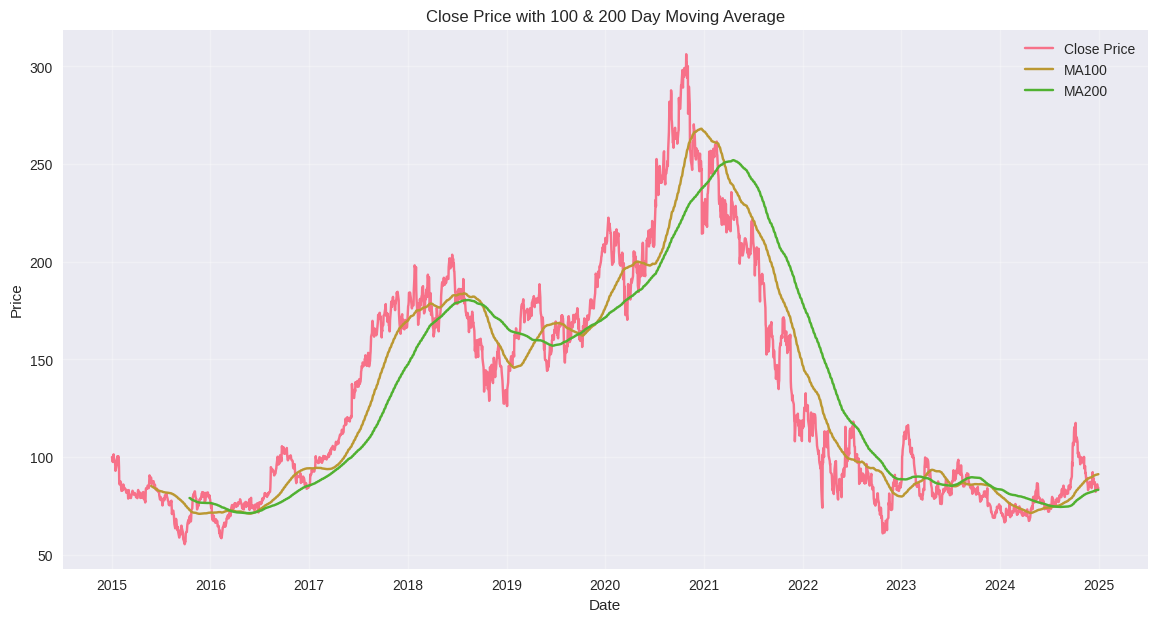

In [ ]:
# moving averages
df['MA100'] = df['Close'].rolling(100).mean()
df['MA200'] = df['Close'].rolling(200).mean()

# Plot EDA
plt.figure(figsize=(14,7))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA100'], label='MA100')
plt.plot(df['Date'], df['MA200'], label='MA200')
plt.title('Close Price with 100 & 200 Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 2. DATA PREPROCESSING - FIXED SCALING
print("\n2. DATA PREPROCESSING...")

# Menggunakan Close price sebagai target
data = df['Close'].values.reshape(-1, 1)

# Parameter
SEQUENCE_LENGTH = 60 # Menggunakan 60 hari sebelumnya untuk prediksi
TRAIN_SIZE = 0.8

# Split data TERLEBIH DAHULU (SEBELUM SCALING)
train_size = int(len(data) * TRAIN_SIZE)
train_data = data[:train_size]
test_data = data[train_size:]

print(f"Original data shape: {data.shape}")
print(f"Train data size: {len(train_data)}")
print(f"Test data size: {len(test_data)}")


2. DATA PREPROCESSING...
Original data shape: (2515, 1)
Train data size: 2012
Test data size: 503


In [ ]:
# SCALING YANG BENAR - FIT HANYA PADA TRAIN DATA
scaler = MinMaxScaler(feature_range=(0, 1))
# Fit scaler hanya pada train data
train_scaled = scaler.fit_transform(train_data)
# Transform test data menggunakan parameter dari train data
test_scaled = scaler.transform(test_data)

print(f"Train scaled data range: {train_scaled.min():.4f} to {train_scaled.max():.4f}")
print(f"Test scaled data range: {test_scaled.min():.4f} to {test_scaled.max():.4f}")

Train scaled data range: 0.0000 to 1.0000
Test scaled data range: 0.0446 to 0.2475


In [ ]:
# Function untuk membuat sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Buat sequences untuk train dan test
X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH)

In [ ]:
# Untuk test data, kita perlu gabungkan sedikit train data agar bisa buat sequences
# Ambil 60 data terakhir dari train untuk membuat sequence pertama test
combined_data = np.concatenate([train_scaled[-SEQUENCE_LENGTH:], test_scaled])
X_test, y_test = create_sequences(combined_data, SEQUENCE_LENGTH)

print(f"\nTraining sequences shape: {X_train.shape}")
print(f"Training targets shape: {y_train.shape}")
print(f"Testing sequences shape: {X_test.shape}")
print(f"Testing targets shape: {y_test.shape}")

# Reshape untuk LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"\nReshaped training data: {X_train.shape}")
print(f"Reshaped testing data: {X_test.shape}")


Training sequences shape: (1952, 60)
Training targets shape: (1952,)
Testing sequences shape: (503, 60)
Testing targets shape: (503,)

Reshaped training data: (1952, 60, 1)
Reshaped testing data: (503, 60, 1)


In [ ]:
# 3. MODEL BUILDING
print("\n3. BUILDING LSTM MODEL...")
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

print("\nModel Architecture:")
model.summary()


3. BUILDING LSTM MODEL...

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,101 (203.52 KB)

 Trainable params: 52,101 (203.52 KB)

 Non-trainable params: 0 (0.00 B)


4. TRAINING MODEL...
Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0596 - mae: 0.1693 - val_loss: 0.0026 - val_mae: 0.0404 - learning_rate: 0.0010
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - loss: 0.0047 - mae: 0.0482 - val_loss: 0.0022 - val_mae: 0.0374 - learning_rate: 0.0010
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0029 - mae: 0.0386 - val_loss: 0.0020 - val_mae: 0.0353 - learning_rate: 0.0010
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0029 - mae: 0.0393 - val_loss: 0.0018 - val_mae: 0.0336 - learning_rate: 0.0010
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0028 - mae: 0.0381 - val_loss: 0.0018 - val_mae: 0.0330 - learning_rate: 0.0010
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0027 - mae: 0.0368 - val_loss: 0.0028 - val_mae: 0.0429 - learning_rate: 0.0010
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0023 - mae: 0.0344 - val_loss: 0.0019 - val_mae: 0.0350 - lea

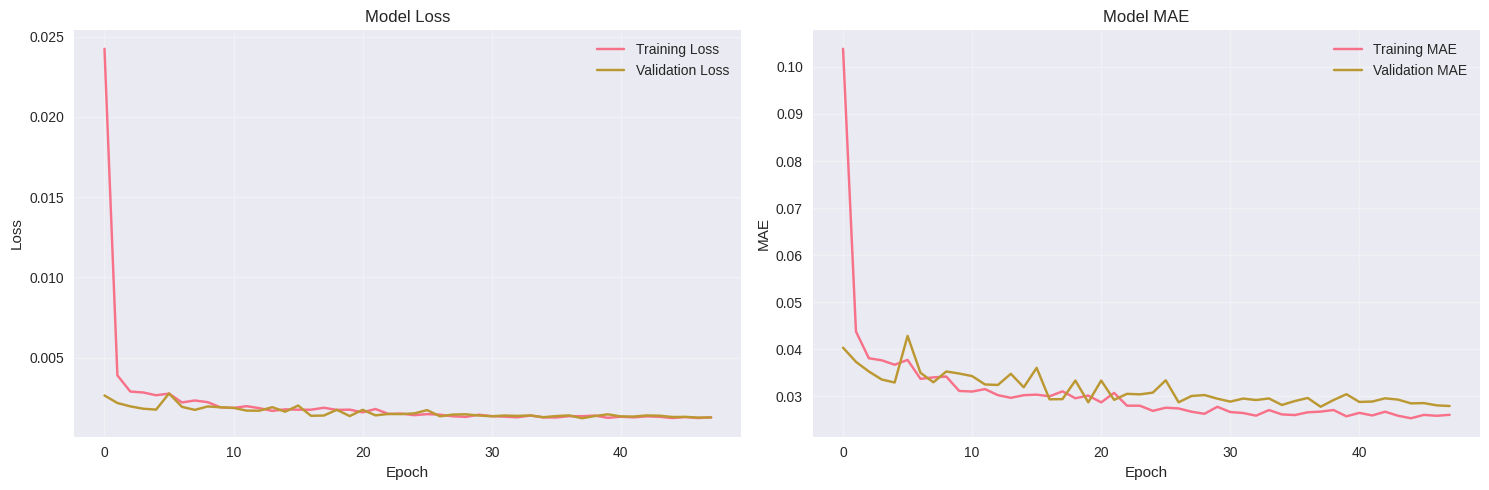

In [ ]:
# 4. TRAINING
print("\n4. TRAINING MODEL...")
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.0001
)

# Training
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Plot training history
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 5. PREDICTIONS
print("\n5. MAKING PREDICTIONS...")
# Prediksi pada data training dan testing
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Inverse transform untuk mendapatkan nilai asli
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Train predictions shape: {train_predictions.shape}")
print(f"Test predictions shape: {test_predictions.shape}")


5. MAKING PREDICTIONS...
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
Train predictions shape: (1952, 1)
Test predictions shape: (503, 1)


In [ ]:
# 6. EVALUATION
print("\n6. MODEL EVALUATION...")

# Function MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero_idx = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero_idx] - y_pred[nonzero_idx]) / y_true[nonzero_idx])) * 100
    return mape

# Metrics untuk training data
train_mse = mean_squared_error(y_train_actual, train_predictions)
train_mae = mean_absolute_error(y_train_actual, train_predictions)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, train_predictions)
train_mape = mean_absolute_percentage_error(y_train_actual, train_predictions)

# Metrics untuk testing data
test_mse = mean_squared_error(y_test_actual, test_predictions)
test_mae = mean_absolute_error(y_test_actual, test_predictions)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, test_predictions)
test_mape = mean_absolute_percentage_error(y_test_actual, test_predictions)

print("\nTRAINING METRICS:")
print(f"MSE : {train_mse:.4f}")
print(f"MAE : {train_mae:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R²  : {train_r2:.4f}")
print(f"MAPE: {train_mape:.2f}%")

print("\nTESTING METRICS:")
print(f"MSE : {test_mse:.4f}")
print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")
print(f"MAPE: {test_mape:.2f}%")

# Percentage accuracy
train_accuracy = 100 - (train_mae / np.mean(y_train_actual) * 100)
test_accuracy = 100 - (test_mae / np.mean(y_test_actual) * 100)

print(f"\nTRAINING ACCURACY: {train_accuracy:.2f}%")
print(f"TESTING ACCURACY: {test_accuracy:.2f}%")


6. MODEL EVALUATION...

TRAINING METRICS:
MSE : 67.1464
MAE : 6.0320
RMSE: 8.1943
R²  : 0.9800
MAPE: 4.20%

TESTING METRICS:
MSE : 27.2723
MAE : 3.9384
RMSE: 5.2223
R²  : 0.7702
MAPE: 4.55%

TRAINING ACCURACY: 95.87%
TESTING ACCURACY: 95.30%



7. CREATING VISUALIZATIONS...


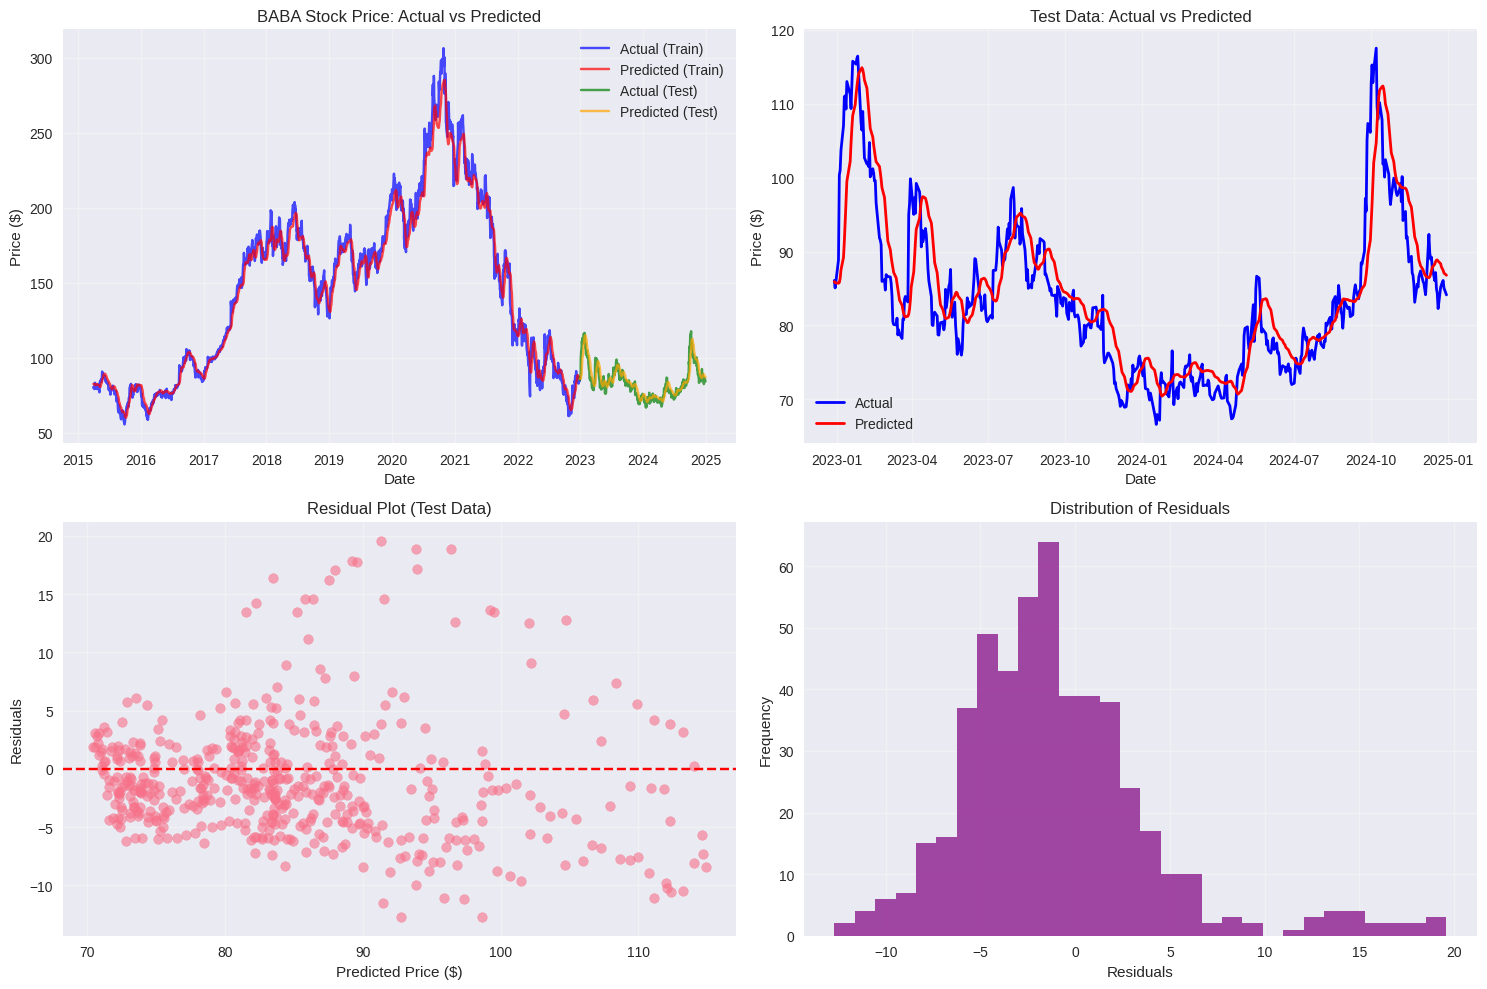

In [ ]:
# 7. VISUALIZATION
print("\n7. CREATING VISUALIZATIONS...")
# Prepare data for plotting
train_dates = df['Date'][SEQUENCE_LENGTH:train_size].values
test_dates = df['Date'][train_size:].values

plt.figure(figsize=(15, 10))

# Plot 1: Full prediction vs actual
plt.subplot(2, 2, 1)
plt.plot(train_dates, y_train_actual, label='Actual (Train)', color='blue', alpha=0.7)
plt.plot(train_dates, train_predictions, label='Predicted (Train)', color='red', alpha=0.7)
plt.plot(test_dates, y_test_actual, label='Actual (Test)', color='green', alpha=0.7)
plt.plot(test_dates, test_predictions, label='Predicted (Test)', color='orange', alpha=0.7)
plt.title('BABA Stock Price: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Focus on test data
plt.subplot(2, 2, 2)
plt.plot(test_dates, y_test_actual, label='Actual', color='blue', linewidth=2)
plt.plot(test_dates, test_predictions, label='Predicted', color='red', linewidth=2)
plt.title('Test Data: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Residuals
plt.subplot(2, 2, 3)
residuals = y_test_actual.flatten() - test_predictions.flatten()
plt.scatter(test_predictions.flatten(), residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (Test Data)')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residuals')
plt.grid(True, alpha=0.3)

# Plot 4: Distribution of residuals
plt.subplot(2, 2, 4)
plt.hist(residuals, bins=30, alpha=0.7, color='purple')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 8. FUTURE FORECASTING
print("\n8. FUTURE FORECASTING...")
# Forecast untuk 30 hari ke depan
forecast_days = 30

# Ambil sequence terakhir dari data scaled yang sudah digabung
last_sequence = combined_data[-SEQUENCE_LENGTH:]
forecast_predictions = []

for _ in range(forecast_days):
    # Reshape untuk prediksi
    input_seq = last_sequence.reshape((1, SEQUENCE_LENGTH, 1))
    # Prediksi
    next_pred = model.predict(input_seq, verbose=0)
    forecast_predictions.append(next_pred[0, 0])
    # Update sequence
    last_sequence = np.append(last_sequence[1:], next_pred[0, 0])

# Inverse transform forecast
forecast_predictions = np.array(forecast_predictions).reshape(-1, 1)
forecast_prices = scaler.inverse_transform(forecast_predictions)

# Create dates for forecast
last_date = df['Date'].iloc[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)

print(f"Forecasting {forecast_days} days into the future...")
print(f"Forecast date range: {forecast_dates[0]} to {forecast_dates[-1]}")


8. FUTURE FORECASTING...
Forecasting 30 days into the future...
Forecast date range: 2024-12-31 00:00:00 to 2025-01-29 00:00:00


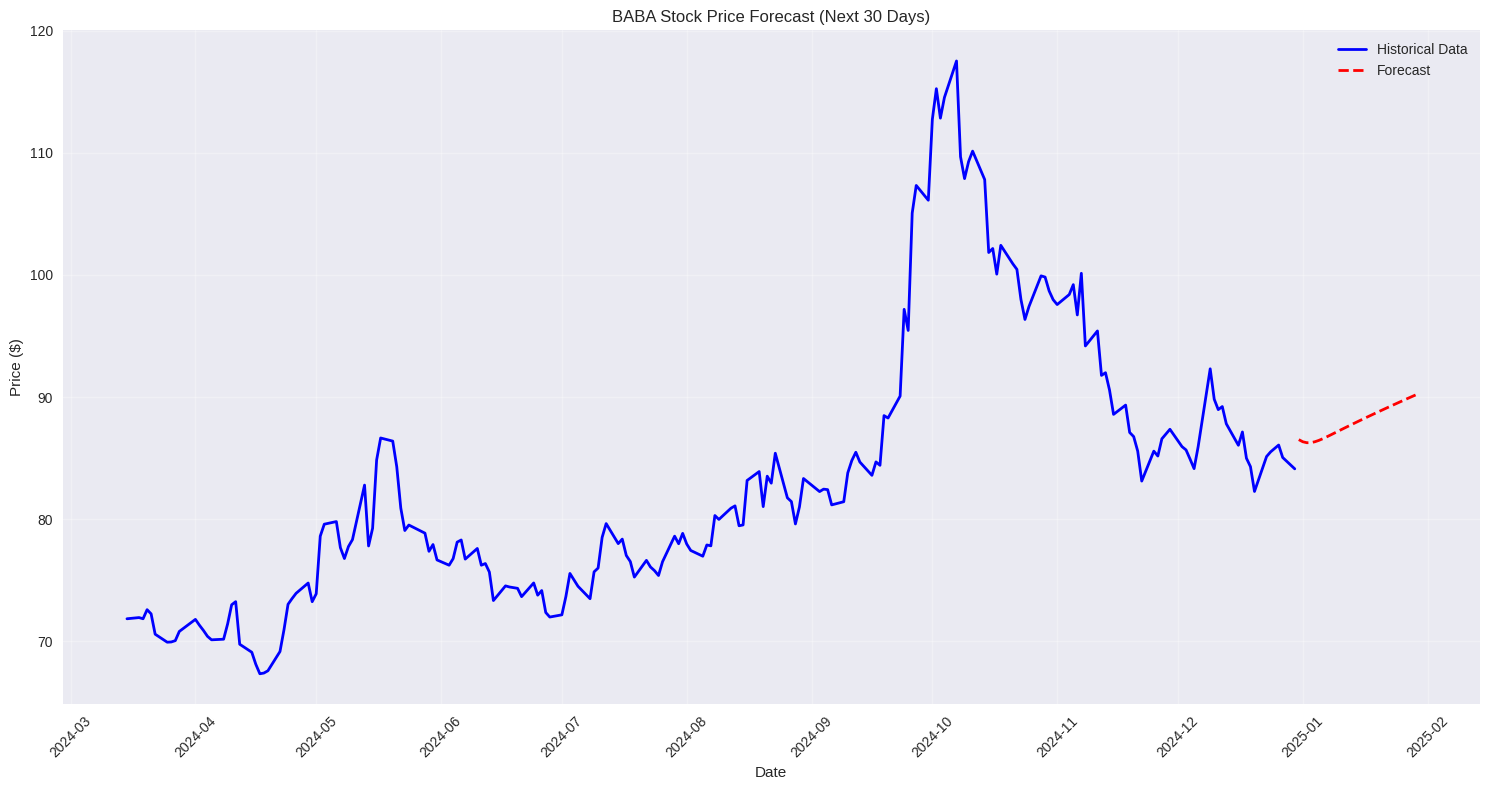


SUMMARY REPORT

DATA SUMMARY:
• Total data points: 2515
• Date range: 2015-01-02 to 2024-12-30
• Training period: 2012 days (80.0%)
• Testing period: 503 days (20.0%)

MODEL PERFORMANCE:
• Training R²: 0.9800
• Testing R²: 0.7702
• Training RMSE: $8.19
• Testing RMSE: $5.22
• Training MAPE: 4.20%
• Testing MAPE: 4.55%
• Training Accuracy: 95.87%
• Testing Accuracy: 95.30%

FORECAST SUMMARY:
• Current price: $84.13
• 30-day forecast range: $86.27 - $90.18
• Predicted price in 30 days: $90.18
• Expected 30-day change: +7.19%

FORECAST VALUES (Next 30 Days):
2024-12-31: $86.52
2025-01-01: $86.35
2025-01-02: $86.27
2025-01-03: $86.28
2025-01-04: $86.35
2025-01-05: $86.46
2025-01-06: $86.60
2025-01-07: $86.76
2025-01-08: $86.92
2025-01-09: $87.09
...
2025-01-25: $89.59
2025-01-26: $89.74
2025-01-27: $89.89
2025-01-28: $90.03
2025-01-29: $90.18

ANALYSIS COMPLETE!


In [ ]:
# Plot forecast
plt.figure(figsize=(15, 8))
# Plot historical data (last 200 days)
historical_data = df.tail(200)
plt.plot(historical_data['Date'], historical_data['Close'],
         label='Historical Data', color='blue', linewidth=2)

# Plot forecast
plt.plot(forecast_dates, forecast_prices,
         label='Forecast', color='red', linewidth=2, linestyle='--')

plt.title('BABA Stock Price Forecast (Next 30 Days)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 10. SUMMARY REPORT
print("\n" + "="*60)
print("SUMMARY REPORT")
print("="*60)

print(f"\nDATA SUMMARY:")
print(f"• Total data points: {len(df)}")
print(f"• Date range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"• Training period: {train_size} days ({TRAIN_SIZE*100:.1f}%)")
print(f"• Testing period: {len(test_data)} days ({(1-TRAIN_SIZE)*100:.1f}%)")

print(f"\nMODEL PERFORMANCE:")
print(f"• Training R²: {train_r2:.4f}")
print(f"• Testing R²: {test_r2:.4f}")
print(f"• Training RMSE: ${train_rmse:.2f}")
print(f"• Testing RMSE: ${test_rmse:.2f}")
print(f"• Training MAPE: {train_mape:.2f}%")
print(f"• Testing MAPE: {test_mape:.2f}%")
print(f"• Training Accuracy: {train_accuracy:.2f}%")
print(f"• Testing Accuracy: {test_accuracy:.2f}%")

print(f"\nFORECAST SUMMARY:")
print(f"• Current price: ${df['Close'].iloc[-1]:.2f}")
print(f"• 30-day forecast range: ${forecast_prices.min():.2f} - ${forecast_prices.max():.2f}")
print(f"• Predicted price in 30 days: ${forecast_prices[-1][0]:.2f}")

change_30d = ((forecast_prices[-1][0] - df['Close'].iloc[-1]) / df['Close'].iloc[-1]) * 100
print(f"• Expected 30-day change: {change_30d:+.2f}%")

# Show forecast values
print(f"\nFORECAST VALUES (Next 30 Days):")
for i, (date, price) in enumerate(zip(forecast_dates, forecast_prices)):
    if i < 10 or i >= len(forecast_dates) - 5:  # Show first 10 and last 5
        print(f"{date.strftime('%Y-%m-%d')}: ${price[0]:.2f}")
    elif i == 10:
        print("...")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)